# employee data analysis

## 1. Setup and Imports

In [25]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.impute import KNNImputer 
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr, f_oneway, ttest_ind
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
CUR_DIR = Path.cwd().resolve()


### 1.1 load dataset

In [ ]:
df_raw = pd.read_csv(CUR_DIR / 'dataset/employee_2023.csv', sep=',', index_col=None)

## 2. Initial Data Exploration - Getting to Know Our Data

Before diving into cleaning, we need to understand what we're working with.


In [ ]:
print("=" * 80)
print(" INITIAL DATA EXPLORATION")
print("=" * 80)

print(f"   Features: {df_raw.dtypes}")
print(f"\n First look at the data:")
display(df_raw.head())

print(f"\n Dataset Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print(f"\n Memory Usage: {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB")

# Data types and completeness
print("\n Data Types and Completeness:")
dtype_summary = pd.DataFrame({
    'Data Type': df_raw.dtypes,
    'Non-Null Count': df_raw.notnull().sum(),
    'Null Count': df_raw.isnull().sum(),
    'Null %': (df_raw.isnull().sum() / len(df_raw) * 100).round(1),
    'Unique Values': df_raw.nunique()
})

# Numerical columns overview
print("\n Quick Statistical Summary (Numeric Columns):")
display(df_raw.describe().round(2))

# Categorical columns overview
print("\n Categorical Columns Overview:")
cat_cols = df_raw.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != 'name':
        print(f"\n{col}:")
        print(df_raw[col].value_counts().to_string()) # todo: hire_date too long (shwo first couple rows) 


## 3. Data Quality Assessment - Systematic Problem Finding
Now we audit every column against rules.
### Good data rules:
1. COMPLETENESS - All required values are present
2. VALIDITY - Values follow business rules
3. CONSISTENCY - Values make sense together
4. UNIQUENESS - No unwanted duplicates
5. ACCURACY - Values reflect reality (hard to verify)

In [ ]:
class DataQualityAssessor:
    """
    data quality assessment.
    """
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.rules = self._define_rules()
        self.quality_report = {}
        
    def _define_rules(self) -> dict:
        """Define business rules that data must satisfy."""
        return {
            "Age must be positive (18-70)": 
                (self.df["age"] > 0) & (self.df["age"] <= 70),
            "Salary must be reasonable ($20k-$500k)": 
                (self.df["salary"] > 20000) & (self.df["salary"] < 500000),
            "Performance score must be 0-100": 
                (self.df["performance_score"] >= 0) & (self.df["performance_score"] <= 100),
            "Projects completed must be non-negative": 
                self.df["projects_completed"] >= 0,
            "Overtime hours must be non-negative": 
                self.df["overtime_hours"] >= 0,
            "Tenure must be non-negative": 
                self.df["tenure_years"] >= 0,
            "Team size must be positive": 
                self.df["team_size"] > 0,
            "Hire date cannot be in the future": 
                pd.to_datetime(self.df['hire_date']).dt.date <= datetime.now().date(),
            "Satisfaction must be a valid category": 
                self.df["satisfaction"].isin(['Very Low', 'Low', 'Medium', 'High', 'Very High'])
        }
    
    def assess(self) -> dict:
        """Run quality assessment."""
        
        # Check completeness
        completeness = pd.DataFrame({
            'Column': self.df.columns,
            'Missing': self.df.isnull().sum(),
            'Complete %': ((1 - self.df.isnull().sum() / len(self.df)) * 100).round(1)
        }).sort_values('Missing', ascending=False)
        
        # Check validity (business rules)
        violations = {}
        for rule, condition in self.rules.items():
            violations[rule] = (~condition.fillna(True)).sum()
        
        # Check uniqueness
        duplicates = self.df.duplicated().sum()
        id_duplicates = self.df['employee_id'].duplicated().sum()
        
        # quality score
        total_checks = len(self.df) * len(self.rules)
        total_violations = sum(violations.values())
        quality_score = (1 - total_violations / total_checks) * 100
        
        self.quality_report = {
            'completeness': completeness,
            'violations': pd.Series(violations),
            'duplicate_rows': duplicates,
            'duplicate_ids': id_duplicates,
            'quality_score': quality_score
        }
        
        return self.quality_report
    
    def print_report(self):
        """Print a quality report."""
        if not self.quality_report:
            self.assess()
        
        r = self.quality_report
        
        print("=" * 80)
        print(" DATA QUALITY ASSESSMENT REPORT")
        print("=" * 80)
        
        print(f"\n Overall Quality Score: {r['quality_score']:.1f}%")
        
        print(f"\n Completeness Issues:")
        missing = r['completeness'][r['completeness']['Missing'] > 0]
        if len(missing) > 0:
            display(missing)
        else:
            print(" No missing values found")
        
        print(f"\n Business Rule Violations:")
        violations = r['violations'][r['violations'] > 0]
        if len(violations) > 0:
            for rule, count in violations.items():
                pct = (count / len(self.df)) * 100
                print(f"   • {rule}: {count} violations ({pct:.1f}%)")
        else:
            print(" No rule violations found")
        
        print(f"\n Uniqueness:")
        print(f"   - Duplicate rows: {r['duplicate_rows']}")
        print(f"   - Duplicate employee IDs: {r['duplicate_ids']}")

assessor = DataQualityAssessor(df_raw)
assessor.assess()
assessor.print_report()

## 4. Missing Data Analysis - Understanding Why Data is Missing
key assertions: 
- Before we can fix missing data, we need to understand **WHY** it's missing.
- Different types of missingness require **different handling strategies**.


In [ ]:
print("=" * 80)
print(" MISSING DATA ANALYSIS")
print("=" * 80)

# Visualize missing patterns
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

msno.matrix(df_raw, ax=axes[0], fontsize=8)
axes[0].set_title('Missing Data Matrix\n(White lines = missing values)', 
                  fontsize=12, fontweight='bold')

msno.heatmap(df_raw, ax=axes[1])
axes[1].set_title('Correlation of Missingness\n(Higher numbers = missing together)', 
                  fontsize=12, fontweight='bold')

msno.bar(df_raw, ax=axes[2])
axes[2].set_title('Data Completeness by Column', 
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Analyze MAR patterns - is salary missingness related to department?
print("\n MAR Analysis: Is salary missingness related to department?")
missing_by_dept = pd.crosstab(
    df_raw['department'],
    df_raw['salary'].isna(),
    normalize='index'
)
missing_by_dept.columns = ['Has Salary', 'Missing Salary']
display(missing_by_dept)

# Analyze MNAR patterns - is overtime missingness related to overtime values?
print("\n MNAR Analysis: Is overtime missingness related to overtime values?")
ot_median = df_raw['overtime_hours'].median()
high_ot = df_raw[df_raw['overtime_hours'] > ot_median]
low_ot = df_raw[df_raw['overtime_hours'] <= ot_median]
print(f"   High overtime missing rate: {high_ot['overtime_hours'].isna().mean()*100:.1f}%")
print(f"   Low overtime missing rate: {low_ot['overtime_hours'].isna().mean()*100:.1f}%")
print(f"   Difference: This suggests MNAR - missingness depends on the value itself")

# Visualize the three mechanisms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MCAR
mcar_cols = ['projects_completed', 'training_completed', 'team_size']
mcar_missing = df_raw[mcar_cols].isna().sum()
axes[0].bar(mcar_cols, mcar_missing, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_title('MCAR: Random Missing\n(No pattern, ~5% each)', fontweight='bold')
axes[0].set_ylabel('Missing Count')

# MAR
dept_missing = df_raw.groupby('department')['salary'].apply(lambda x: x.isna().mean() * 100)
axes[1].bar(dept_missing.index, dept_missing.values, color='#e67e22')
axes[1].set_title('MAR: Salary Missing by Dept\n(HR has more missing)', fontweight='bold')
axes[1].set_ylabel('Missing %')
axes[1].tick_params(axis='x', rotation=45)

# MNAR
axes[2].bar(['Low OT\n(≤ median)', 'High OT\n(> median)'],
           [low_ot['overtime_hours'].isna().mean()*100,
            high_ot['overtime_hours'].isna().mean()*100],
           color=['#2ecc71', '#e74c3c'])
axes[2].set_title('MNAR: OT Missing by Value\n(High OT = more missing)', fontweight='bold')
axes[2].set_ylabel('Missing %')

plt.suptitle('Three Types of Missing Data Mechanisms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Data Cleaning - Fixing What's Broken

- Fix the issues we found. 

In [ ]:
class DataCleaner:
    """
    Systematic data cleaning with full traceability.
    """
    
    def __init__(self):
        self.cleaning_log = []
    
    def clean(self, df: pd.DataFrame) -> pd.DataFrame:
        """Execute complete cleaning pipeline."""
        df_clean = df.copy()
        print(" Starting data cleaning...\n")
        
        # Remove duplicates
        df_clean = self._remove_duplicates(df_clean)
        
        # Fix data types
        df_clean = self._fix_dates(df_clean)
        
        # Fix categorical typos
        df_clean = self._fix_categories(df_clean)
        
        # Handle impossible values
        df_clean = self._fix_impossible_values(df_clean)
        
        # Handle outliers
        df_clean = self._handle_outliers(df_clean)
        
        print(f"\n Cleaning complete. {len(self.cleaning_log)} actions performed.")
        return df_clean
    
    def _remove_duplicates(self, df):
        """Remove exact and near-duplicate records."""
        before = len(df)
        
        # Remove exact duplicates
        df = df.drop_duplicates()
        exact_dupes = before - len(df)
        
        # Remove duplicate employee IDs (keep most recent record)
        if df['employee_id'].duplicated().any():
            df = df.sort_values('hire_date').drop_duplicates('employee_id', keep='last')
        
        after = len(df)
        self._log(f"Removed {exact_dupes} exact duplicate rows")
        if before - after > exact_dupes:
            self._log(f"Removed {before - after - exact_dupes} duplicate employee IDs")
        
        return df.reset_index(drop=True)
    
    def _fix_dates(self, df):
        """Fix impossible dates."""
        # Convert to datetime
        df['hire_date'] = pd.to_datetime(df['hire_date'])
        
        # Fix future dates
        future = df['hire_date'] > pd.Timestamp.now()
        if future.sum() > 0:
            df.loc[future, 'hire_date'] = df.loc[future, 'hire_date'].apply(
                lambda d: d.replace(year=d.year - 1)
            )
            self._log(f"Corrected {future.sum()} future hire dates")
        
        return df
    
    def _fix_categories(self, df):
        """Standardize categorical values."""
        # Fix satisfaction typos
        satisfaction_map = {
            'vlow': 'Very Low', 'Vlow': 'Very Low',
            'low ': 'Low', 'LOW': 'Low',
            'medium': 'Medium',
            'high': 'High', 'HIGH': 'High',
            'very high': 'Very High'
        }
        
        if 'satisfaction' in df.columns:
            original_unique = df['satisfaction'].nunique()
            df['satisfaction'] = df['satisfaction'].str.strip().str.title()
            df['satisfaction'] = df['satisfaction'].replace(satisfaction_map)
            new_unique = df['satisfaction'].nunique()
            
            if original_unique != new_unique:
                self._log(f"Standardized satisfaction values from {original_unique} to {new_unique} unique categories")
        
        return df
    
    def _fix_impossible_values(self, df):
        """Fix values that can't possibly be correct."""
        
        # Negative ages -> likely data entry error, use absolute value
        neg_ages = (df['age'] < 0).sum()
        if neg_ages > 0:
            df.loc[df['age'] < 0, 'age'] = df.loc[df['age'] < 0, 'age'].abs()
            self._log(f"Corrected {neg_ages} negative ages to positive")
        
        # Ages over 70 -> flag but keep (could be legitimate)
        old_ages = (df['age'] > 70).sum()
        if old_ages > 0:
            df['age_flag'] = df['age'] > 70
            self._log(f"Flagged {old_ages} ages over 70 for review")
        
        return df
    
    def _handle_outliers(self, df):
        """Handle outliers carefully - flag rather than delete."""
        
        # Salary outliers - flag and cap for analysis
        salary_bounds = df['salary'].quantile([0.01, 0.99]).values
        salary_outliers = (df['salary'] < salary_bounds[0]) | (df['salary'] > salary_bounds[1])
        
        if salary_outliers.sum() > 0:
            df['salary_outlier'] = salary_outliers
            df['salary_original'] = df['salary'].copy()
            df['salary'] = df['salary'].clip(*salary_bounds)
            self._log(f"Flagged and capped {salary_outliers.sum()} salary outliers")
        
        # Overtime outliers
        ot_bounds = df['overtime_hours'].quantile([0.01, 0.99]).values
        ot_outliers = (df['overtime_hours'] < ot_bounds[0]) | (df['overtime_hours'] > ot_bounds[1])
        
        if ot_outliers.sum() > 0:
            df['ot_outlier'] = ot_outliers
            df['overtime_hours'] = df['overtime_hours'].clip(*ot_bounds)
            self._log(f"Flagged and capped {ot_outliers.sum()} overtime outliers")
        
        return df
    
    def _log(self, message):
        """Record cleaning action for audit trail."""
        self.cleaning_log.append(message)
        print(f"   + {message}")

cleaner = DataCleaner()
df_clean = cleaner.clean(df_raw)

print("\n Post-Cleaning Quality Check:")
final_assessor = DataQualityAssessor(df_clean)
final_assessor.assess()
final_assessor.print_report()


## 6. Missing Value Imputation
key assertion:
- Now we fill in the remaining missing values. We use different strategies
- for different types of data because one size doesn't fit all.


In [ ]:
print("=" * 80)
print(" MISSING VALUE IMPUTATION")
print("=" * 80)

def plot_improvements(k_values, mse_scores, optimal_k=None):
    """Plot elbow curve with selected `k`"""
    
    global plt
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(k_values, mse_scores, marker='o', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Neighbors (k)', fontsize=12)
    axes[0].set_ylabel('Mean Squared Error', fontsize=12)
    axes[0].set_title('Elbow Method: Finding Optimal k for KNN Imputation', 
                     fontsize=13, fontweight='bold')
    if optimal_k is not None:
        axes[0].axvline(x=optimal_k, color='red', linestyle='--', alpha=0.5, label=f'Selected k={optimal_k}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Show improvement
    improvement = np.abs(np.diff(mse_scores) / mse_scores[:-1] * 100)
    axes[1].bar(range(2, 16), improvement)
    axes[1].set_xlabel('Number of Neighbors (k)', fontsize=12)
    axes[1].set_ylabel('Improvement from Previous k (%)', fontsize=12)
    axes[1].set_title('Marginal Improvement per Additional Neighbor', 
                     fontsize=13, fontweight='bold')
    axes[1].axhline(y=5, color='red', linestyle='--', alpha=0.5, 
                   label='5% threshold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Separate numeric and categorical columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['employee_id', 'age_flag', 
                                                       'salary_outlier', 'ot_outlier']]
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"\n Numeric columns to impute: {numeric_cols}")
print(f" Categorical columns to impute: {cat_cols}")

# First, let's find optimal k for KNN imputation
print("\n Finding optimal k for KNN imputation...")

# Use salary as test case (has clear missing values)
salary_complete = df_clean[['salary', 'age', 'tenure_years', 'performance_score']].dropna()
if len(salary_complete) > 100:
    # Create artificial missing values for testing
    np.random.seed(42)
    mask = np.random.rand(len(salary_complete)) < 0.2
    salary_missing = salary_complete.copy()
    salary_missing.loc[mask, 'salary'] = np.nan
    
    # Test different k values
    k_values = range(1, 16)
    mse_scores = []
    
    for k in k_values:
        imputer = KNNImputer(n_neighbors=k)
        imputed = imputer.fit_transform(salary_missing)
        mse = mean_squared_error(
            salary_complete['salary'][mask],
            imputed[mask, 0]
        )
        mse_scores.append(mse)
    plot_improvements(k_values, mse_scores) # plot improvements

    optimal_k = int(input('choose number of clusters (`k` value):')) # `4`` is optimal ask to choose `k` value (number of clusters)
    print(f"   Selected k = {optimal_k} (balance between accuracy and overfitting)")
    plot_improvements(k_values, mse_scores, optimal_k) # plot improvements

# Apply imputation
print("\n Applying KNN imputation to numeric columns...")
imputer_knn = KNNImputer(n_neighbors=optimal_k)
df_clean[numeric_cols] = imputer_knn.fit_transform(df_clean[numeric_cols])
print(f"    Imputed {len(numeric_cols)} numeric columns")

# Categorical columns - use mode (most frequent value)
print("\n Applying mode imputation to categorical columns...")
cat_missing = df_clean[cat_cols].isnull().sum()
cat_missing = cat_missing[cat_missing > 0]

for col in cat_missing.index:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"   + Imputed {col} with mode: '{mode_val}'")

print(f"\n Imputation complete! Remaining missing values: {df_clean.isnull().sum().sum()}")



## 7. Feature Engineering - Creating Meaningful Variables
- Raw data is rarely in the right form for analysis. We create derived features
- that capture business concepts more directly.


In [ ]:

print("=" * 80)
print(" FEATURE ENGINEERING")
print("=" * 80)

df_featured = df_clean.copy()

# --- Time-based features ---
df_featured['hire_year'] = df_featured['hire_date'].dt.year
df_featured['years_since_hire'] = (pd.Timestamp.now() - df_featured['hire_date']).dt.days / 365.25

# --- Tenure segments ---
df_featured['tenure_segment'] = pd.cut(
    df_featured['tenure_years'],
    bins=[0, 1, 3, 5, 10, 30],
    labels=['New Hire (<1yr)', 'Junior (1-3yr)', 'Mid (3-5yr)', 
            'Senior (5-10yr)', 'Veteran (10+yr)']
)

# --- Salary features ---
# Salary relative to department median (equity metric)
dept_median_salary = df_featured.groupby('department')['salary'].transform('median')
df_featured['salary_vs_dept_median_pct'] = (
    (df_featured['salary'] - dept_median_salary) / dept_median_salary * 100
).round(1)

# Salary per year of tenure (career progression proxy)
df_featured['salary_per_tenure_year'] = (
    df_featured['salary'] / df_featured['tenure_years'].clip(lower=0.5)
).round(0)

# --- Performance features ---
# Performance category
df_featured['performance_category'] = pd.cut(
    df_featured['performance_score'],
    bins=[0, 30, 50, 70, 85, 100],
    labels=['Needs Improvement', 'Meets Expectations', 
            'Exceeds Expectations', 'Outstanding', 'Exceptional']
)

# Performance relative to department average
dept_avg_perf = df_featured.groupby('department')['performance_score'].transform('mean')
df_featured['perf_vs_dept_avg'] = (
    df_featured['performance_score'] - dept_avg_perf
).round(1)

# --- Workload features ---
# Overtime intensity
df_featured['overtime_intensity'] = pd.cut(
    df_featured['overtime_hours'],
    bins=[0, 5, 10, 20, 100],
    labels=['Low', 'Moderate', 'High', 'Excessive']
)

# Project efficiency
df_featured['projects_per_year'] = (
    df_featured['projects_completed'] / df_featured['tenure_years'].clip(lower=0.5)
).round(1)

# --- Satisfaction ---
satisfaction_numeric = {'Very Low': 1, 'Low': 2, 'Medium': 3, 'High': 4, 'Very High': 5}
df_featured['satisfaction_score'] = df_featured['satisfaction'].map(satisfaction_numeric)

# --- Risk features ---
# Composite turnover risk score
df_featured['turnover_risk'] = 0

# Low satisfaction = major risk factor
df_featured.loc[df_featured['satisfaction_score'] <= 2, 'turnover_risk'] += 3

# High overtime + low satisfaction = burnout
df_featured.loc[
    (df_featured['overtime_intensity'].isin(['High', 'Excessive'])) & 
    (df_featured['satisfaction_score'] <= 2),
    'turnover_risk'
] += 2

# Below median salary = flight risk
df_featured.loc[df_featured['salary_vs_dept_median_pct'] < -15, 'turnover_risk'] += 1

# First year = adjustment risk
df_featured.loc[df_featured['tenure_years'] < 1, 'turnover_risk'] += 1

# High performer + low satisfaction = poaching risk
df_featured.loc[
    (df_featured['performance_category'].isin(['Outstanding', 'Exceptional'])) & 
    (df_featured['satisfaction_score'] <= 2),
    'turnover_risk'
] += 2

df_featured['turnover_risk_level'] = pd.cut(
    df_featured['turnover_risk'],
    bins=[-1, 2, 5, 10],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print(" Created derived features:")
new_features = [c for c in df_featured.columns if c not in df_clean.columns]
for f in new_features:
    print(f"   • {f}")

print(f"\n Final dataset: {df_featured.shape[0]} rows x {df_featured.shape[1]} columns")



## 8. Quantifying Data (Descriptive Statistics)

- Now we describe every variable systematically. This is how we understand
- what's "normal" in our organization.


In [ ]:

print("=" * 80)
print(" DESCRIPTIVE STATISTICS")
print("=" * 80)

# Select key numeric columns for analysis
analysis_cols = ['age', 'salary', 'performance_score', 'projects_completed',
                'tenure_years', 'overtime_hours', 'team_size', 'satisfaction_score',
                'salary_vs_dept_median_pct', 'perf_vs_dept_avg', 'turnover_risk']

# Central Tendency
print("\n CENTRAL TENDENCY (What's typical?)")
print("-" * 60)
ct_df = pd.DataFrame({
    'Mean': df_featured[analysis_cols].mean(),
    'Median': df_featured[analysis_cols].median(),
    'Mode': df_featured[analysis_cols].mode().iloc[0],
    'Mean-Median Diff': df_featured[analysis_cols].mean() - df_featured[analysis_cols].median()
}).round(2)

display(ct_df)
# print(tabulate(ct_df, headers='keys', tablefmt='grid'))
print("\n Interpretation: Mean > Median = right-skewed (common in salary data)")
print("   Mean ≈ Median = symmetric distribution")

# Dispersion
print("\n DISPERSION (How spread out is the data?)")
print("-" * 60)
disp_df = pd.DataFrame({
    'Std Dev': df_featured[analysis_cols].std(),
    'IQR': df_featured[analysis_cols].quantile(0.75) - df_featured[analysis_cols].quantile(0.25),
    'CV (%)': (df_featured[analysis_cols].std() / df_featured[analysis_cols].mean() * 100),
    'Range': df_featured[analysis_cols].max() - df_featured[analysis_cols].min()
}).round(2)

display(ct_df)
# print(tabulate(disp_df, headers='keys', tablefmt='grid'))
print("\n Interpretation: CV < 25% = low variability, CV > 50% = high variability")

# Distribution Shape
print("\n DISTRIBUTION SHAPE (Skewness & Kurtosis)")
print("-" * 60)
shape_df = pd.DataFrame({
    'Skewness': df_featured[analysis_cols].skew(),
    'Kurtosis': df_featured[analysis_cols].kurtosis(),
}).round(2)

# Add interpretation
shape_df['Skew Type'] = shape_df['Skewness'].apply(
    lambda x: 'Right-skewed' if x > 0.5 
    else 'Left-skewed' if x < -0.5 
    else 'Symmetric ✓'
)
shape_df['Kurtosis Type'] = shape_df['Kurtosis'].apply(
    lambda x: 'Heavy tails' if x > 0.5 
    else 'Light tails' if x < -0.5 
    else 'Normal-like ✓'
)

display(ct_df)


## 9. Visual Analysis - Seeing the Patterns

- lets visualize data for clear picture

In [ ]:
# Distribution plots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

plot_cols = ['age', 'salary', 'performance_score', 'overtime_hours', 
             'tenure_years', 'projects_completed', 'team_size', 
             'satisfaction_score', 'turnover_risk']

for i, col in enumerate(plot_cols):
    data = df_featured[col].dropna()
    axes[i].hist(data, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(), color='#e74c3c', linestyle='--', linewidth=2, 
                   label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='#2ecc71', linestyle=':', linewidth=2, 
                   label=f'Median: {data.median():.1f}')
    axes[i].set_title(f'{col}\nSkew: {data.skew():.2f}', fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribution of Key Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Box plots by department
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

dept_cols = ['salary', 'performance_score', 'overtime_hours', 
             'tenure_years', 'satisfaction_score', 'turnover_risk']

for i, col in enumerate(dept_cols):
    sns.boxplot(data=df_featured, x='department', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Department', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Comparing Key Metrics Across Departments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Correlation Analysis - Finding Relationships

- Lets find what variables move together. This helps us understand cause and effect.


In [ ]:
print("=" * 80)
print(" CORRELATION ANALYSIS")
print("=" * 80)

# Select numeric columns for correlation
corr_cols = ['age', 'salary', 'performance_score', 'projects_completed',
             'tenure_years', 'overtime_hours', 'team_size', 'satisfaction_score',
             'salary_vs_dept_median_pct', 'perf_vs_dept_avg', 'turnover_risk']

corr_df = df_featured[corr_cols].dropna()

# Calculate all three correlation types
pearson_corr = corr_df.corr(method='pearson')
spearman_corr = corr_df.corr(method='spearman')
kendall_corr = corr_df.corr(method='kendall')

# Plot correlation heatmaps
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

correlations = [
    ('Pearson (Linear)', pearson_corr, axes[0]),
    ('Spearman (Rank)', spearman_corr, axes[1]),
    ('Kendall (Ordinal)', kendall_corr, axes[2])
]

for title, corr, ax in correlations:
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, square=True, ax=ax,
                cbar_kws={"shrink": .8})
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Correlation Matrices: Three Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find strongest correlations
print("\n Strongest Correlations with Turnover Risk:") # todo: make feature name as `turnover_risk` as input from user
turnover_corr = pearson_corr['turnover_risk'].drop('turnover_risk').sort_values(ascending=False)
for var, corr in turnover_corr.head(5).items():
    direction = "positive" if corr > 0 else "negative"
    strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
    print(f"   • {var}: {corr:.3f} ({strength} {direction})")



## 11. Statistical Hypothesis Testing

- We've seen patterns - now let's test them statistically.


In [ ]:
print("=" * 80)
print(" HYPOTHESIS TESTING")
print("=" * 80)

results = {}

# H1: "High overtime leads to lower satisfaction"
print("\nHypothesis 1: High overtime → Lower satisfaction")
median_ot = df_featured['overtime_hours'].median()
high_ot = df_featured[df_featured['overtime_hours'] > median_ot]['satisfaction_score']
low_ot = df_featured[df_featured['overtime_hours'] <= median_ot]['satisfaction_score']

t_stat, p_val = ttest_ind(high_ot, low_ot)
cohens_d = (high_ot.mean() - low_ot.mean()) / np.sqrt((high_ot.var() + low_ot.var()) / 2)

results['H1'] = {
    'high_ot_mean': high_ot.mean(),
    'low_ot_mean': low_ot.mean(),
    'difference': high_ot.mean() - low_ot.mean(),
    'p_value': p_val,
    'cohens_d': cohens_d,
    'significant': p_val < 0.05
}

print(f"   High OT satisfaction: {high_ot.mean():.2f}")
print(f"   Low OT satisfaction:  {low_ot.mean():.2f}")
print(f"   Difference: {high_ot.mean() - low_ot.mean():.2f}")
print(f"   p-value: {p_val:.4f} {'Significant' if p_val < 0.05 else 'Not significant'}")
print(f"   Effect size (Cohen's d): {cohens_d:.2f}")

# H2: "Salary differs by department"
print("\n Hypothesis 2: Salary differs by department")
dept_groups = [group['salary'].dropna().values 
               for name, group in df_featured.groupby('department')]
f_stat, p_val_dept = f_oneway(*dept_groups)

results['H2'] = {
    'f_statistic': f_stat,
    'p_value': p_val_dept,
    'significant': p_val_dept < 0.05
}

print(f"   F-statistic: {f_stat:.2f}")
print(f"   p-value: {p_val_dept:.4f} {'Significant' if p_val_dept < 0.05 else 'Not significant'}")

# H3: "Satisfaction predicts turnover risk"
print("\n Hypothesis 3: Satisfaction → Turnover risk")
satisfaction_groups = [group['turnover_risk'].dropna().values 
                      for name, group in df_featured.groupby('satisfaction_score')]
f_stat_sat, p_val_sat = f_oneway(*satisfaction_groups)

# Also check correlation
sat_risk_corr, sat_risk_p = pearsonr(
    df_featured['satisfaction_score'].dropna(),
    df_featured['turnover_risk'].dropna()
)

results['H3'] = {
    'f_statistic': f_stat_sat,
    'p_value': p_val_sat,
    'correlation': sat_risk_corr,
    'significant': p_val_sat < 0.05
}

print(f"   Correlation (satisfaction vs turnover risk): {sat_risk_corr:.3f}")
print(f"   p-value: {p_val_sat:.4f} {'Significant' if p_val_sat < 0.05 else 'Not significant'}")

# Visualize hypothesis results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# H1 Visualization
axes[0].bar(['Low Overtime', 'High Overtime'], 
           [low_ot.mean(), high_ot.mean()],
           color=['#2ecc71', '#e74c3c'])
axes[0].set_title(f'H1: Overtime → Satisfaction\np={p_val:.4f}', fontweight='bold')
axes[0].set_ylabel('Mean Satisfaction Score')

# H2 Visualization
dept_means = df_featured.groupby('department')['salary'].mean().sort_values()
axes[1].bar(range(len(dept_means)), dept_means.values, color='#3498db')
axes[1].set_xticks(range(len(dept_means)))
axes[1].set_xticklabels(dept_means.index, rotation=45)
axes[1].set_title(f'H2: Salary by Department\np={p_val_dept:.4f}', fontweight='bold')
axes[1].set_ylabel('Mean Salary ($)')

# H3 Visualization
for sat_score, group in df_featured.groupby('satisfaction_score'):
    axes[2].scatter(sat_score, group['turnover_risk'].mean(), 
                   s=group['turnover_risk'].count()/10, alpha=0.6)
axes[2].set_xlabel('Satisfaction Score')
axes[2].set_ylabel('Mean Turnover Risk')
axes[2].set_title(f'H3: Satisfaction → Turnover Risk\nr={sat_risk_corr:.3f}, p={sat_risk_p:.4f}', 
                 fontweight='bold')

plt.suptitle('Hypothesis Testing Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Cross-Sectional Analysis - Comparing Groups

- Aggregates can hide important differences between groups.


In [ ]:
print("=" * 80)
print(" CROSS-SECTIONAL ANALYSIS")
print("=" * 80)

# Department summary
print("\n Department Comparison:")
dept_summary = df_featured.groupby('department').agg({
    'employee_id': 'count',
    'salary': ['mean', 'median'],
    'performance_score': 'mean',
    'satisfaction_score': 'mean',
    'overtime_hours': 'median',
    'tenure_years': 'mean',
    'turnover_risk': 'mean'
}).round(1)

dept_summary.columns = ['Count', 'Avg Salary', 'Med Salary', 'Avg Performance',
                        'Avg Satisfaction', 'Med Overtime', 'Avg Tenure', 'Avg Risk']
display(dept_summary)

# Satisfaction by department
print("\n Satisfaction Distribution by Department:")
sat_dept = pd.crosstab(df_featured['department'], df_featured['satisfaction'],
                       normalize='index') * 100
display(sat_dept.round(1))

# Turnover risk analysis
print("\n  Turnover Risk Analysis:")
risk_summary = df_featured.groupby('turnover_risk_level').agg({
    'employee_id': 'count',
    'salary': 'mean',
    'performance_score': 'mean',
    'satisfaction_score': 'mean',
    'overtime_hours': 'mean',
    'tenure_years': 'mean'
}).round(1)

risk_summary.columns = ['Count', 'Avg Salary', 'Avg Performance', 
                        'Avg Satisfaction', 'Avg Overtime', 'Avg Tenure']
risk_summary['% of Total'] = (risk_summary['Count'] / len(df_featured) * 100).round(1)
display(risk_summary)



## 13. Insights

- insights formulation


In [29]:

print("=" * 80)
print(" KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 80)

insights = []

# Insight 1: Overtime Impact
ot_effect = results['H1']
if ot_effect['significant']:
    insights.append({
        'title': 'Overtime is Driving Down Satisfaction',
        'finding': (
            f"Employees working above median overtime ({median_ot:.0f} hrs/week) "
            f"report {abs(ot_effect['difference']):.1f} points lower satisfaction "
            f"(effect size: Cohen's d = {ot_effect['cohens_d']:.2f})"
        ),
        'impact': 'High overtime correlates with burnout and increased turnover risk.',
        'recommendation': [
            'Implement overtime monitoring with alerts',
            'Review workload distribution, especially in Engineering and IT',
        ]
    })

# Insight 2: Department Equity
dept_effect = results['H2']
if dept_effect['significant']:
    insights.append({
        'title': 'Department Salary Differences Require Review',
        'finding': (
            f"Significant salary differences exist between departments "
            f"(ANOVA F={dept_effect['f_statistic']:.1f}, p={dept_effect['p_value']:.4f})"
        ),
        'impact': 'Perceived pay inequity can lead to dissatisfaction and turnover.',
        'recommendation': [
            'Conduct compensation review',
        ]
    })

# Insight 3: Turnover Risk Factors
risk_profile = df_featured.groupby('turnover_risk_level')['employee_id'].count()
high_risk_pct = risk_profile.get('High Risk', 0) / len(df_featured) * 100

insights.append({
    'title': 'Identifiable Turnover Risk Factors',
    'finding': (
        f"{high_risk_pct:.1f}% of employees are classified as High Risk. "
        f"Key drivers: low satisfaction, high overtime, below-median salary."
    ),
    'impact': f'Potential loss of {risk_profile.get("High Risk", 0)} employees represents significant replacement cost.',
    'recommendation': [
        'Create retention plans for high-risk employees'
    ]
})

# Insight 4: New Hire Experience
new_hires = df_featured[df_featured['tenure_segment'] == 'New Hire (<1yr)']
veterans = df_featured[df_featured['tenure_segment'] == 'Veteran (10+yr)']

insights.append({
    'title': 'First-Year Experience Needs Improvement',
    'finding': (
        f"New hires show {(veterans['satisfaction_score'].mean() - new_hires['satisfaction_score'].mean()):.1f} "
        f"points lower satisfaction than veterans. "
        f"They also complete fewer projects and have higher overtime."
    ),
    'impact': 'Poor first-year experience leads to early turnover, wasting recruitment investment.',
    'recommendation': [
        'Enhance onboarding program for new employee',
    ]
})

# Print all insights
for i, insight in enumerate(insights, 1):
    print(f"\n{'='*60}")
    print(f"INSIGHT {i}: {insight['title']}")
    print(f"{'='*60}")
    print(f"\n Finding: {insight['finding']}")
    print(f"\n  Impact: {insight['impact']}")
    print(f"\n Recommendations:")
    for j, rec in enumerate(insight['recommendation'], 1):
        print(f"   {j}. {rec}")


 KEY INSIGHTS & RECOMMENDATIONS

INSIGHT 1: Overtime is Driving Down Satisfaction

 Finding: Employees working above median overtime (10 hrs/week) report 0.4 points lower satisfaction (effect size: Cohen's d = -0.43)

  Impact: High overtime correlates with burnout and increased turnover risk.

 Recommendations:
   1. Implement overtime monitoring with alerts
   2. Review workload distribution, especially in Engineering and IT

INSIGHT 2: Identifiable Turnover Risk Factors

 Finding: 8.8% of employees are classified as High Risk. Key drivers: low satisfaction, high overtime, below-median salary.

  Impact: Potential loss of 88 employees represents significant replacement cost.

 Recommendations:
   1. Create retention plans for high-risk employees

INSIGHT 3: First-Year Experience Needs Improvement

 Finding: New hires show -0.2 points lower satisfaction than veterans. They also complete fewer projects and have higher overtime.

  Impact: Poor first-year experience leads to early turno


## 14. Executive Dashboard

- A one-page summary for leadership.

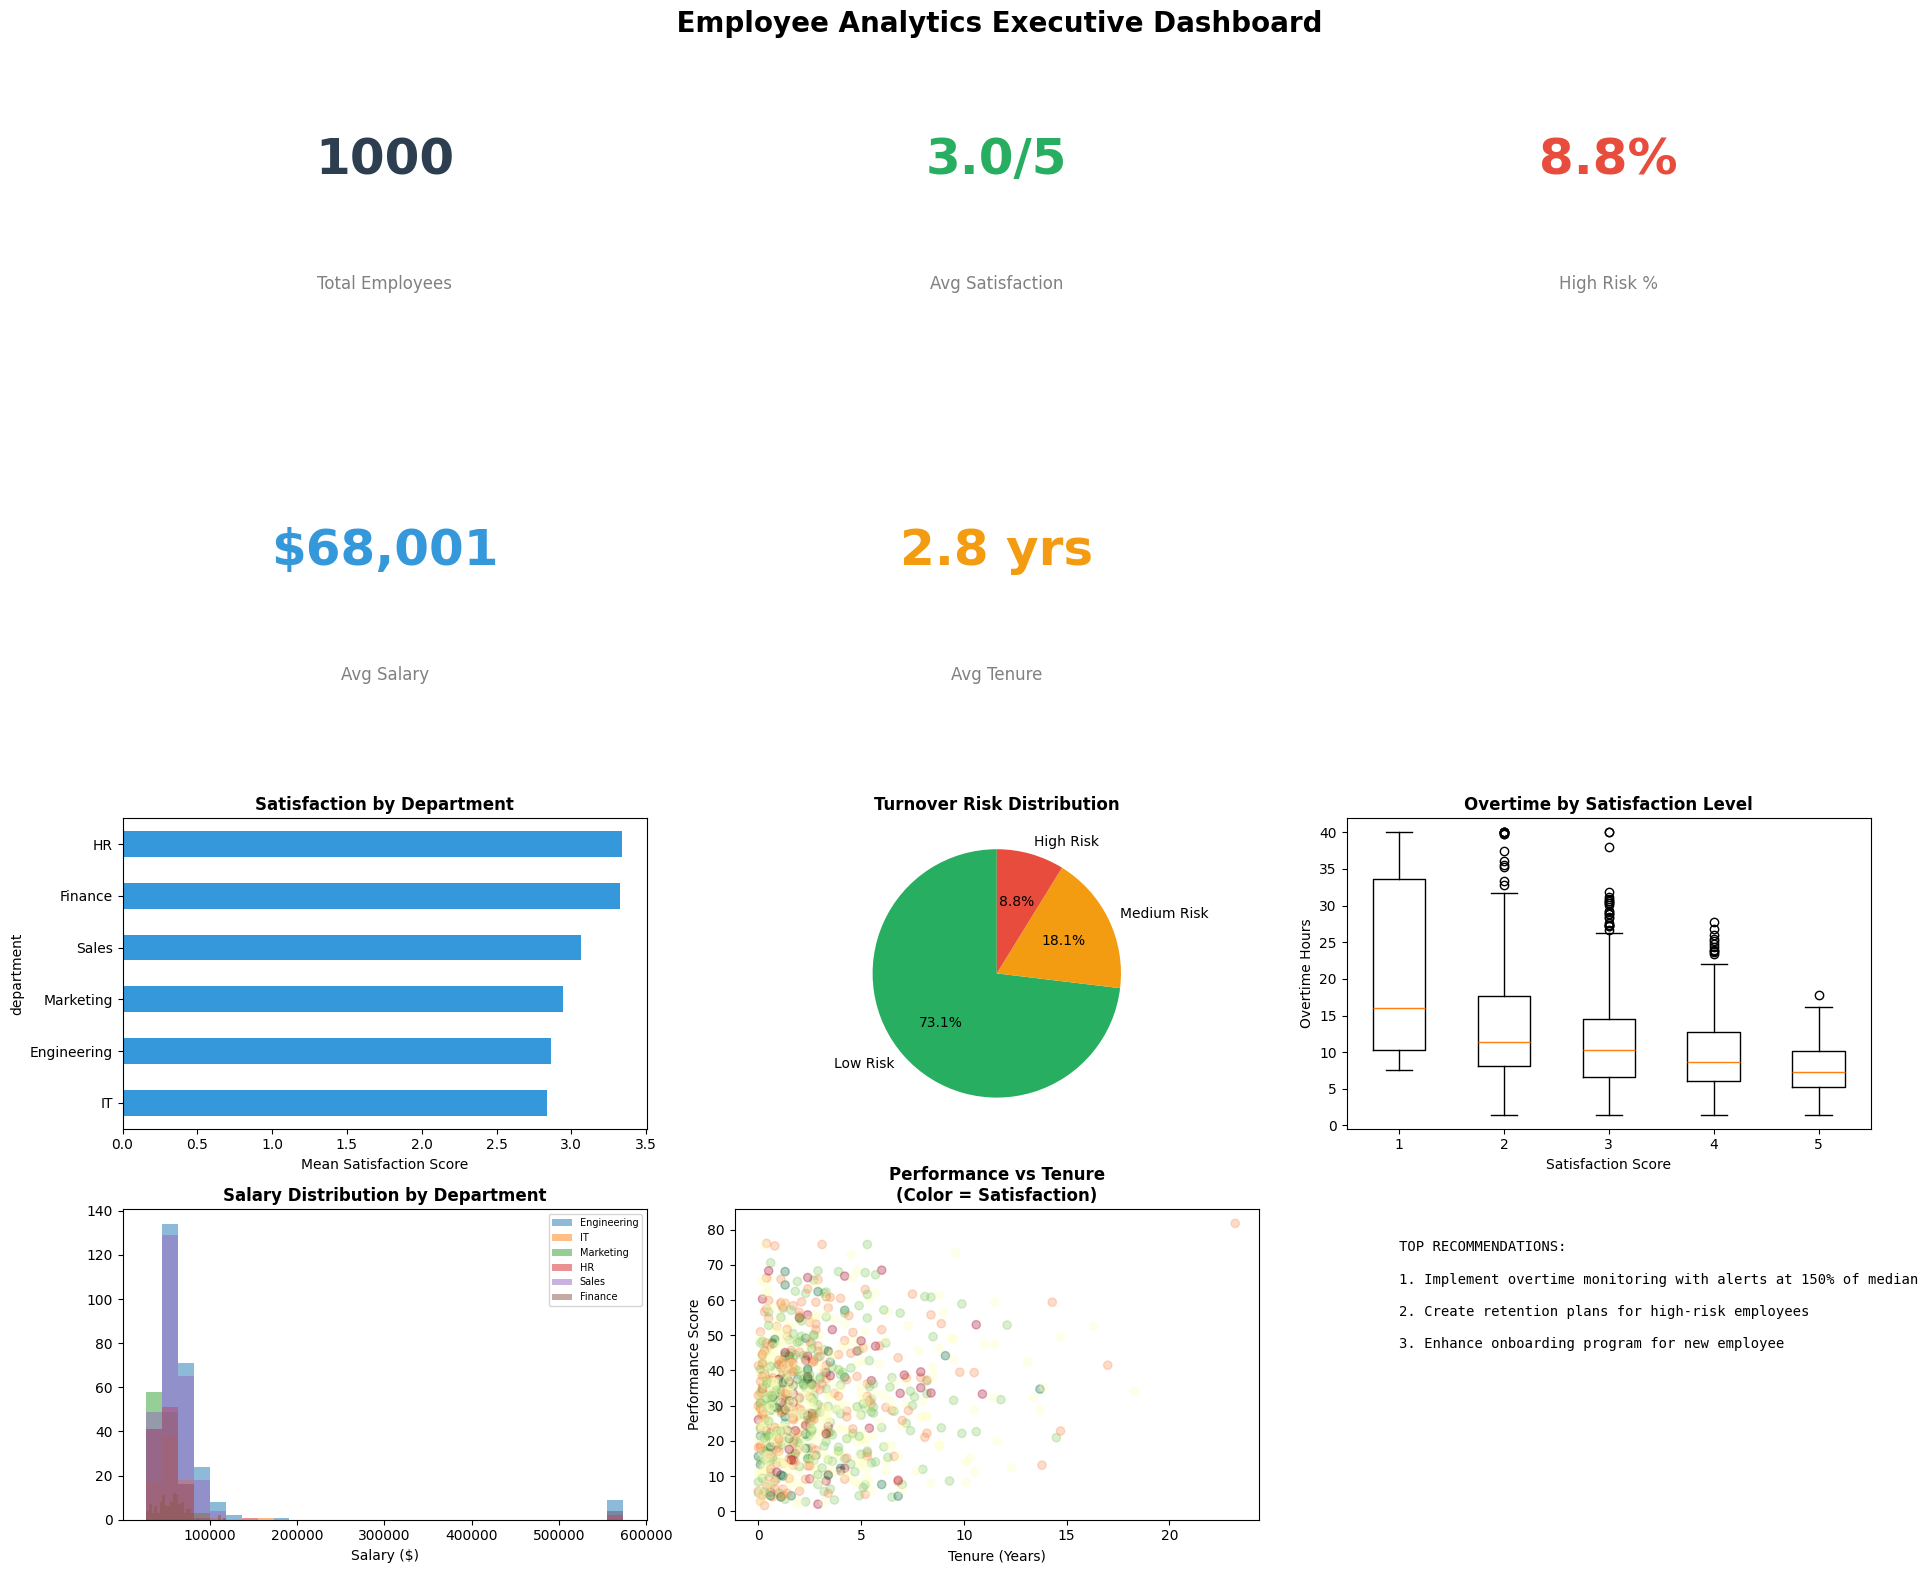

In [28]:
fig = plt.figure(figsize=(20, 16))

# Title
fig.suptitle(' Employee Analytics Executive Dashboard', 
            fontsize=20, fontweight='bold', y=0.98)

# Key Metrics Row
metrics = [
    ('Total Employees', len(df_featured), '#2c3e50'),
    ('Avg Satisfaction', f"{df_featured['satisfaction_score'].mean():.1f}/5", '#27ae60'),
    ('High Risk %', f"{high_risk_pct:.1f}%", '#e74c3c'),
    ('Avg Salary', f"${df_featured['salary'].mean():,.0f}", '#3498db'),
    ('Avg Tenure', f"{df_featured['tenure_years'].mean():.1f} yrs", '#f39c12'),
]

for i, (label, value, color) in enumerate(metrics):
    ax = plt.subplot(4, 3, i+1)
    ax.text(0.5, 0.6, str(value), ha='center', va='center', 
           fontsize=36, fontweight='bold', color=color)
    ax.text(0.5, 0.2, label, ha='center', va='center', fontsize=12, color='gray')
    ax.axis('off')

# Department Satisfaction
ax1 = plt.subplot(4, 3, 7)
dept_sat = df_featured.groupby('department')['satisfaction_score'].mean().sort_values()
dept_sat.plot(kind='barh', ax=ax1, color='#3498db')
ax1.set_title('Satisfaction by Department', fontweight='bold')
ax1.set_xlabel('Mean Satisfaction Score')

# Turnover Risk Distribution
ax2 = plt.subplot(4, 3, 8)
risk_colors = {'Low Risk': '#27ae60', 'Medium Risk': '#f39c12', 'High Risk': '#e74c3c'}
risk_counts = df_featured['turnover_risk_level'].value_counts()
ax2.pie(risk_counts.values, labels=risk_counts.index, 
       colors=[risk_colors.get(x, '#95a5a6') for x in risk_counts.index],
       autopct='%1.1f%%', startangle=90)
ax2.set_title('Turnover Risk Distribution', fontweight='bold')

# Overtime by Satisfaction
ax3 = plt.subplot(4, 3, 9)
for sat_level in sorted(df_featured['satisfaction_score'].unique()):
    data = df_featured[df_featured['satisfaction_score'] == sat_level]['overtime_hours']
    ax3.boxplot([data], positions=[sat_level], widths=0.5)
ax3.set_title('Overtime by Satisfaction Level', fontweight='bold')
ax3.set_xlabel('Satisfaction Score')
ax3.set_ylabel('Overtime Hours')

# Salary Distribution
ax4 = plt.subplot(4, 3, 10)
for dept in df_featured['department'].unique():
    data = df_featured[df_featured['department'] == dept]['salary']
    ax4.hist(data, bins=30, alpha=0.5, label=dept)
ax4.set_title('Salary Distribution by Department', fontweight='bold')
ax4.legend(fontsize=7, loc='upper right')
ax4.set_xlabel('Salary ($)')

# Performance vs Tenure
ax5 = plt.subplot(4, 3, 11)
ax5.scatter(df_featured['tenure_years'], df_featured['performance_score'], 
           alpha=0.3, c=df_featured['satisfaction_score'], cmap='RdYlGn')
ax5.set_title('Performance vs Tenure\n(Color = Satisfaction)', fontweight='bold')
ax5.set_xlabel('Tenure (Years)')
ax5.set_ylabel('Performance Score')

# Top Recommendations
ax6 = plt.subplot(4, 3, 12)
ax6.axis('off')
recommendations_text = "TOP RECOMMENDATIONS:\n\n"
for i, insight in enumerate(insights[:4], 1):
    recommendations_text += f"{i}. {insight['recommendation'][0]}\n\n"
ax6.text(0.1, 0.9, recommendations_text, transform=ax6.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.show()
